<a href="https://colab.research.google.com/github/Lacenedihia/Admin-Dashboard-Back-end-/blob/main/notebooks/01_first_look_and_discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Lacenedihia/flyrank-ml-internship-starter/blob/main/notebooks/01_first_look_and_discovery.ipynb?flush_cache=true)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [ ]:
import os, sys, subprocess
#Imports three standard library modules: os (filesystem/OS operations), sys (interpreter/system info), subprocess (run external commands).
IN_COLAB = "google.colab" in sys.modules
#if google.colab has been imported (which happens automatically in a Colab notebook), this evaluates to True
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    #If the repo folder doesn't already exist, it clones it with git clone --depth 1 (a shallow clone — only the latest commit, no history — to save time/bandwidth).
#Changes the working directory into the cloned repo.
#Installs the repo's Python dependencies from requirements.txt using pip, run quietly (-q). It uses sys.executable (path to the current Python interpreter) rather than just pip, to make sure it installs into the same Python environment Colab is using.
#check=True in each subprocess.run means: if the command fails (non-zero exit code), raise an exception immediately instead of silently continuing.
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")
        #Assumes the repo is already cloned locally, but the notebook's kernel might have started in some subfolder.
        #So it walks up the directory tree (os.chdir("..")) repeatedly until it finds a folder containing data/raw (presumably the repo root), or until it hits the filesystem root / (safety stop so it doesn't loop forever).

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [ ]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py
#The ! means "run this as a shell command, not Python." {sys.executable} gets substituted with the path to the current Python interpreter (so it uses the exact same Python environment the notebook is using, not some other Python that might be installed on the system).

#So this line just means: run the file scripts/run_all.py using this notebook's Python. It's essentially the notebook equivalent of typing this into a terminal:


▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_que

Running that one notebook line kicks off a pipeline that:



1.   Cleans your data and builds features
2.   Builds a simple baseline rule
3.   Trains 3 ML models and compares them
4.   Evaluates the best one and produces a ranked output + charts + report
5.   Packages everything into a shareable PDF



### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

In [ ]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


Pulls out two specific numbers from that dictionary:

base: the baseline's precision@50
rf: the random forest model's precision@50

"Precision@50" is a common ranking-quality metric: if you take the top 50 items your model ranked as most likely to matter (e.g. "pages that need a content refresh"), what fraction of those 50 were actually correct? A precision@50 of 0.60 means 30 out of the top 50 picks were right.


## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.



This section is about letting you explore the raw data yourself and see three things that challenge common "SEO wisdom." Let me walk through each part.

In [ ]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


Loads the anonymized starter CSV into a pandas DataFrame called df.
df.shape returns (rows, columns) — so this prints how big the dataset is.
df.head(3) shows the first 3 rows so you can see what columns exist and what the data actually looks like.


### Discovery A — "High search volume means more traffic." Does it?

In [ ]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


1. impressions_90d is one of the columns in data/raw/content_refresh_anonymized.csv. You can see it referenced in two of the discovery cells
2. **.corr()** computes the Pearson correlation coefficient between the two columns — a number from -1 to 1 that measures how strongly two variables move together. 1 = perfectly move together, 0 = no relationship, -1 = perfectly opposite.
## 3.  

The point: common SEO belief says "target high search-volume keywords and you'll get more traffic." If the correlation comes out near 0, that belief is wrong — a keyword being popular in search doesn't mean your specific page actually gets shown or clicked. That's the "myth-busting" insight of this cell.

### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.


**Where your page ranks in Google search results (position 1 vs position 5 vs position 20) makes a huge difference in how many people click on it.**

1.  CTR (click-through rate): out of everyone who saw your page in search results, what % actually clicked on it? If 100 people saw it and 5 clicked, CTR = 5%.
2.   position_tier: a column that groups pages by roughly where they rank in Google (e.g. "top 3", "positions 4-10", "positions 11-20", etc.)
3.  impressions_90d: how many times the page was shown in search results in the last 90 days.


position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


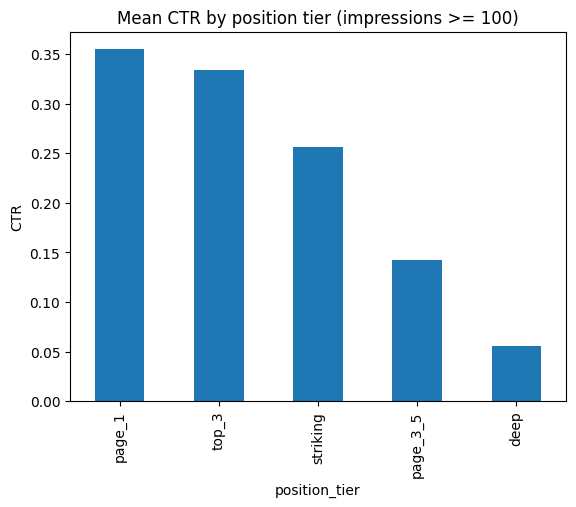

In [ ]:
visible = df[df["impressions_90d"] >= 100]
#only keep rows (pages) that were shown at least 100 times in the last 90 days.
#If a page was only shown 2 times and got 1 click, that's a "50% CTR" — but that's meaningless, it's just luck/noise from a tiny sample.
#Only trust CTR numbers for pages that got seen enough times to be reliable.
#at least a decent number of flips (impressions) before trusting the percentage.

ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)

print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

1. visible = df[df["impressions_90d"] >= 100]: filters down to only pages that had at least 100 impressions — i.e., pages with enough visibility to trust their click-through-rate (CTR) numbers (a page seen only twice would give a noisy/unreliable CTR).
2.  .groupby("position_tier"): groups rows by which "tier" of search ranking position they fall into (e.g., positions 1-3, 4-10, 11-20, etc. — however the dataset buckets them).

3.  ["ctr"].mean() — for each bucket, calculate the average CTR of all pages in it
4.   .sort_values(ascending=False) — arrange the results from highest average CTR to lowest.


 the printed numbers or the bar chart, you'll likely see something like: top-3 positions get way more clicks (proportionally) than position 10, which gets way more than position 20, and so on — a steep drop, not a gentle slope.


### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [ ]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")


*  .groupby("trend_direction")["word_count"].median(): for each trend category,

*   computes the median word count of pages in that group. (Median rather than mean, so a few extremely long/short outlier pages don't skew the comparison.)
The point: a common belief is "just make your content longer and it'll perform better."
If pages trending down have roughly the same median word count as pages

*   trending up, that tells you word count isn't actually what's driving performance — so simply adding more words to a page isn't the fix.


# 1. Redo Discovery A but only for pages with impressions_90d > 0

## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

In [ ]:
# Your discovery here
visible_pages = df[df["impressions_90d"] > 0]
corr_filtered = visible_pages["search_volume"].corr(visible_pages["impressions_90d"])
print(f"Correlation (impressions_90d > 0 only): {corr_filtered:.3f}")
print(f"Original correlation (all rows): {corr:.3f}")

Correlation (impressions_90d > 0 only): 0.001
Original correlation (all rows): 0.001


# 2. Discovery B, which content_type has the worst CTR at the same position tier?

In [ ]:
counts = visible.groupby(["position_tier", "content_type"]).size()
print(counts)

position_tier  content_type      
deep           feedly article          10
               keyword article        869
page_1         comparison article     226
               feedly article         221
               keyword article       8186
page_3_5       comparison article      63
               feedly article          41
               keyword article       5954
striking       comparison article      76
               feedly article          75
               keyword article       5752
top_3          comparison article       1
               feedly article           5
               keyword article        527
dtype: int64


Sample sizes per group:
position_tier  content_type      
deep           feedly article          10
               keyword article        869
page_1         comparison article     226
               feedly article         221
               keyword article       8186
page_3_5       comparison article      63
               feedly article          41
               keyword article       5954
striking       comparison article      76
               feedly article          75
               keyword article       5752
top_3          comparison article       1
               feedly article           5
               keyword article        527

CTR by content_type and position_tier (only groups with >= 30 rows):
position_tier  content_type      
deep           keyword article       0.0555
page_1         comparison article    0.1412
               feedly article        0.9048
               keyword article       0.3458
page_3_5       comparison article    0.0940
               feedly article 

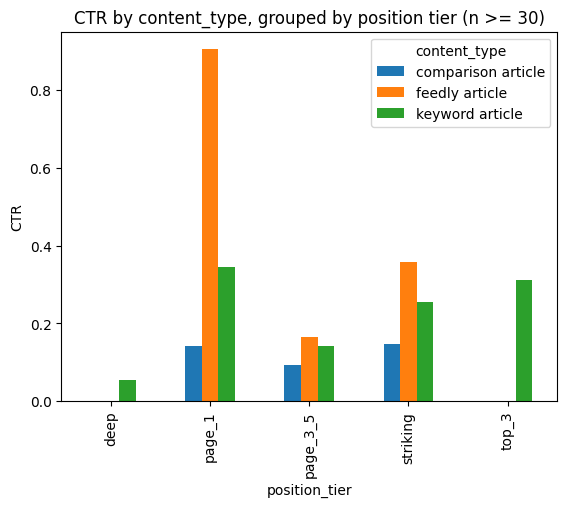

Worst content_type per tier (reliable groups only):
                     content_type       ctr
position_tier                              
deep              keyword article  0.055547
page_1         comparison article  0.141239
page_3_5       comparison article  0.093968
striking       comparison article  0.147368
top_3             keyword article  0.310417


In [ ]:

visible = df[df["impressions_90d"] >= 100]

# Count how many rows support each (position_tier, content_type) combo
counts = visible.groupby(["position_tier", "content_type"]).size()
print("Sample sizes per group:")
print(counts.to_string())
print()

# Only trust groups with enough data
MIN_ROWS = 30
reliable_groups = counts[counts >= MIN_ROWS].index

# Compute CTR by tier and content type, same as before
ctr_by_type_and_pos = visible.groupby(["position_tier", "content_type"])["ctr"].mean()

# Filter down to only the reliable combos
ctr_reliable = ctr_by_type_and_pos[ctr_by_type_and_pos.index.isin(reliable_groups)]
print(f"CTR by content_type and position_tier (only groups with >= {MIN_ROWS} rows):")
print(ctr_reliable.round(4).to_string())
print()

# Rebuild the pivot table using only the filtered data
visible_reliable = visible.merge(
    reliable_groups.to_frame(index=False),
    on=["position_tier", "content_type"],
    how="inner"
)
pivot = visible_reliable.pivot_table(index="position_tier", columns="content_type", values="ctr", aggfunc="mean")
pivot.plot(kind="bar", title=f"CTR by content_type, grouped by position tier (n >= {MIN_ROWS})", ylabel="CTR")
plt.show()

# Worst content_type per tier, only among reliable groups
worst_per_tier = (
    ctr_reliable
    .reset_index()
    .sort_values("ctr")
    .groupby("position_tier")
    .first()
)
print("Worst content_type per tier (reliable groups only):")
print(worst_per_tier)

# 3.  Find another belief to test: does content_age_days relate to trend_direction? Does avg_position relate to ctr?

PART A: content_age_days vs trend_direction

Median content age by trend direction:
trend_direction
down      216.0
flat      231.0
new       279.0
stable    300.0
up        292.0

Row counts per trend_direction group:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152


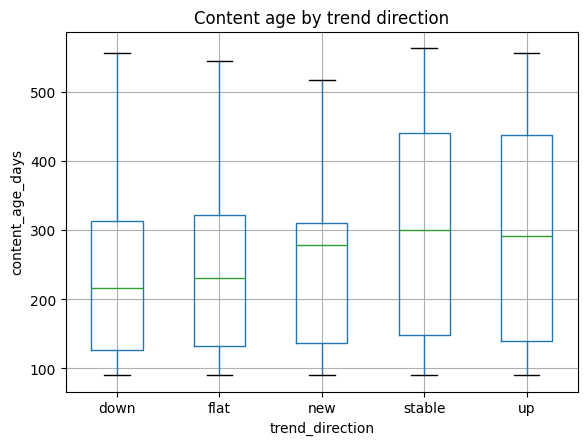


PART B: avg_position vs ctr

Raw correlation (all rows): -0.073
Filtered correlation (impressions_90d >= 100): -0.239


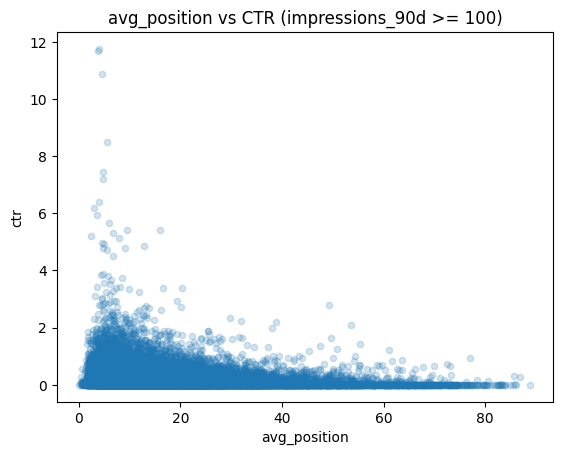

In [ ]:
# ============================================================
# Part A: Does content_age_days relate to trend_direction?
# ============================================================

print("=" * 60)
print("PART A: content_age_days vs trend_direction")
print("=" * 60)

age_by_trend = df.groupby("trend_direction")["content_age_days"].median()
print("\nMedian content age by trend direction:")
print(age_by_trend.round(0).to_string())

# Sample sizes, so we know how much to trust each group
trend_counts = df["trend_direction"].value_counts()
print("\nRow counts per trend_direction group:")
print(trend_counts.to_string())

# Visualize the spread, not just the median
df.boxplot(column="content_age_days", by="trend_direction")
plt.title("Content age by trend direction")
plt.suptitle("")  # removes the default ugly auto-title pandas adds
plt.ylabel("content_age_days")
plt.show()


# ============================================================
# Part B: Does avg_position relate to ctr?
# ============================================================

print("\n" + "=" * 60)
print("PART B: avg_position vs ctr")
print("=" * 60)

# Raw correlation, all rows (includes noisy low-impression pages)
corr_raw = df["avg_position"].corr(df["ctr"])
print(f"\nRaw correlation (all rows): {corr_raw:.3f}")

# Filtered correlation, same reliability filter as Discovery B
visible = df[df["impressions_90d"] >= 100]
corr_filtered = visible["avg_position"].corr(visible["ctr"])
print(f"Filtered correlation (impressions_90d >= 100): {corr_filtered:.3f}")

# Scatter plot to check for a curved (non-linear) relationship
visible.plot(
    kind="scatter", x="avg_position", y="ctr", alpha=0.2,
    title="avg_position vs CTR (impressions_90d >= 100)"
)
plt.show()

Remarks

1. Discovery A, filtered: Correlation stays at 0.001 even after dropping zero-impression pages. Search volume still doesn't predict actual traffic — not a filtering artifact, the relationship really is flat.

2. Discovery B, worst content_type by tier: No single content type is worst everywhere. comparison article has the lowest CTR at page_1, page_3_5, and striking; keyword article is worst at deep and top_3. feedly article actually leads at page_1 (0.90 CTR) but that's only 221 rows, so treat it as directional, not proven. Small-sample groups (e.g. top_3 comparison, n=1) were excluded for reliability.

3. content_age_days vs trend_direction: Declining pages have the youngest median age (216 days), while stable/up pages skew older (~290–300 days). Directionally, this suggests newer content is more likely to be tagged "down" — possibly still settling in rankings — while older content that's survived tends to be steadier. Not causal, just an observed pattern.

4. avg_position vs ctr: Weak negative correlation overall (-0.073), which strengthens to -0.239 once low-impression noise is filtered out. Consistent with Discovery B — better position (lower number) associates with higher CTR — but the relationship is far from tight, so position alone doesn't explain most of the variance in CTR.

General takeaway: Filtering for sample size/reliability changed the picture meaningfully in cases 2–4 (raw vs. filtered numbers diverged), but not in case 1. Worth remembering that "correlation is weak" and "correlation is zero" are different findings — position→CTR is weak-but-real, search volume→traffic is genuinely near-zero.

### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.